Course link: https://www.youtube.com/watch?v=a4HBKEda_F8

# 1. Introdcution
The course is structured in two parts: 
1. Essential Elasticsearch fundamentals: index management, document storage, text analysis, pipeline creation, search functionality, and advanced features like semantic search and embeddings.

2. A practical section where you'll build a real-world website using Elasticsearch as a search engine, working with the Astronomy Picture of the Day (APOD) dataset to implement features such as data cleaning pipelines, tokenization, pagination, and aggregations.


# 2. Installation

1. Make sure docker is installed: https://www.docker.com/
2. Go to the following site and copy the command onto cmd: https://www.elastic.co/search-labs/tutorials/install-elasticsearch/docker


* Linux:\
  docker run -p 127.0.0.1:9200:9200 -d --name elasticsearch \
    -e "discovery.type=single-node" \
    -e "xpack.security.enabled=false" \
    -e "xpack.license.self_generated.type=trial" \
    -v "elasticsearch-data:/usr/share/elasticsearch/data" \
    docker.elastic.co/elasticsearch/elasticsearch:8.15.0


* Windows:\
  docker run -p 127.0.0.1:9200:9200 -d --name elasticsearch -e "discovery.type=single-node" -e "xpack.security.enabled=false" -e "xpack.license.self_generated.type=trial" -v "elasticsearch-data:/usr/share/elasticsearch/data" docker.elastic.co/elasticsearch/elasticsearch:8.15.0




check your container is up and running in http://localhost:9200.

* To stop and remove it, run this in cmd: **docker stop elasticsearch docker rm elasticsearch**
* To stop it but keep it (so you can restart it later): **docker stop elasticsearch**
  Then restart it with: **docker start elasticsearch**
* Check status anytime with: **docker ps -a**
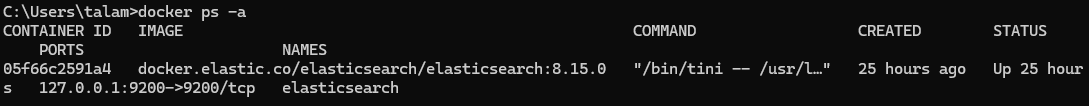

In [1]:
# run this cell to install the necessary dependencies
%pip install "elasticsearch<9"

Note: you may need to restart the kernel to use updated packages.


# 3. Create an Index

## Definitions:
* **Index**: collection of documents that share similar characteristics.
    Can be compared to datasbase in a relational database (i.e. SQL) and optimized for searching large volumes of textual, numeric and structured data.
* **Shard**: each document in the index is divided to a number of shards.
    Ex. If no. shards=2 and no. documents=3 -> Index will have 6 parts instead of 3 full documents.
    Elastticsearch knows how to reconstruct the documents to find the information we need.

* **Replica**: a copy of the data (i.e replica=1 means we duplicate the data once). For system resilience and parallel searching.

In [ ]:
from elasticsearch import Elasticsearch
from pprint import pprint

# Connect to Elasticsearch
es = Elasticsearch("http://localhost:9200")

# Check if the connection is successful
if es.ping():
    print("Connected to Elasticsearch!")

    # Get and print cluster information
    info = es.info()
    pprint(info)
else:
    print("Connection failed.")

Connected to Elasticsearch!
ObjectApiResponse({'name': '05f66c2591a4', 'cluster_name': 'docker-cluster', 'cluster_uuid': 'Yn5zjAt7TUOntAMcWpLSeg', 'version': {'number': '8.15.0', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '1a77947f34deddb41af25e6f0ddb8e830159c179', 'build_date': '2024-08-05T10:05:34.233336849Z', 'build_snapshot': False, 'lucene_version': '9.11.1', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'})


In [4]:
# deleting the index if it already exists
if es.indices.exists(index="my_index"):
    es.indices.delete(index="my_index")
    print("Index 'my_index' deleted.")

# creating an index
index_name = "my_index"
if not es.indices.exists(index=index_name):
    # create the index + change settings: shards and replicas
    es.indices.create(index=index_name, body={"settings": {"number_of_shards": 3, "number_of_replicas": 2}})

    # print the response + check index settings
    response = es.indices.get(index=index_name)
    pprint(response)
else:    
    print(f"Index '{index_name}' already exists.")
    

Index 'my_index' deleted.
ObjectApiResponse({'my_index': {'aliases': {}, 'mappings': {}, 'settings': {'index': {'routing': {'allocation': {'include': {'_tier_preference': 'data_content'}}}, 'number_of_shards': '3', 'provided_name': 'my_index', 'creation_date': '1773243703120', 'number_of_replicas': '2', 'uuid': 'h3Sd8YC6TWafLknSD-yygw', 'version': {'created': '8512000'}}}}})


# 4. Inserting Documents